In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/Evidential_deep_learning')

In [ ]:

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
import torchvision.transforms.functional as TF
from torchvision import transforms as T
import matplotlib.pyplot as plt
from last_layer import Dirichlet
from loss import evidential_classification
from tqdm.notebook import tqdm
device=('cuda' if torch.cuda.is_available() else 'cpu')
import math

In [ ]:

MEAN, STD =0.13,0.31


transform=T.Compose([
      T.ToTensor(),
      T.Normalize((MEAN,),(STD,))
  ])

train_data=MNIST(root='./data',train=True,download=True,transform=transform)
test_data=MNIST(root='./data',train=False,download=True,transform=transform)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.83MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 153kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.4MB/s]


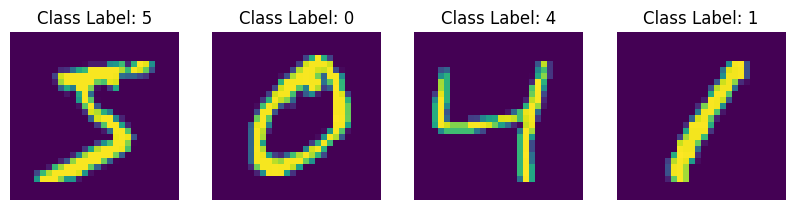

In [ ]:
sample = train_data[0]

img_sample = sample[0].permute(1,2,0)*0.13 + 0.31  # denormalize
fig, axis=plt.subplots(1,4,figsize=(10,10))

for i in range(4):
  sample = train_data[i]
  img_sample = sample[0].permute(1,2,0)

  axis[i].imshow(img_sample)
  axis[i].axis('off')
  axis[i].set_title(f"Class Label: {sample[1]}")
plt.show()



In [ ]:
def model():
  lenet=nn.Sequential(
      nn.Conv2d(1,6,5, padding=2),
      nn.ReLU(),
      nn.MaxPool2d(2,2),
      nn.Conv2d(6,16,5),
      nn.ReLU(),
      nn.MaxPool2d(2,2),
      nn.Flatten(),
      nn.Linear(16*5*5,120),
      nn.ReLU(),
      nn.Linear(120,84),
      nn.ReLU(),
      Dirichlet(84,10)
  )

  return lenet





lenet=model()
lenet.to(device)





def training(model, dataloader, optimizer, device, epoch):
      model.train()
      for x, y in tqdm(dataloader, desc="Training"):
        x=x.to(device)
        y=y.to(device)

        optimizer.zero_grad()
        output=model(x)
        loss=evidential_classification(output,y, lamb=min(1,epoch/10))
        loss.backward()
        optimizer.step()

      return loss.item()

def testing(model, dataloader, device):
    model.eval()
    correct=0
    total=0
    with torch.no_grad():
      for x, y in tqdm(dataloader, desc="Testing"):
        x=x.to(device)
        y=y.to(device)

        output=model(x)

        correct+=(output.argmax(-1)==y).sum().item()
        total+=y.shape[0]

      acc=correct/total
      return acc



def main():
  torch.manual_seed(0)


  training_loader=DataLoader(train_data,batch_size=32,shuffle=True)
  test_loader=DataLoader(test_data,batch_size=32,shuffle=True)
  optimzer=torch.optim.Adam(lenet.parameters(),lr=1e-3)

  for epoch in range(10):
    L_train=training(lenet,training_loader,optimzer,device, epoch)
    acc_test=testing(lenet,test_loader,device)

    print(f'Epoch {epoch}/{10}, training loss: {L_train:.3f}, accuracy: {acc_test:.3f}')








In [ ]:
@torch.no_grad()
def rotation_uncertainty(img, model):
    m = 180
    n = m // 10 + 1
    degs = torch.linspace(0, m, n)
    imgs, probs, uncertainty,prediction = [], [], [], []
    cols = 4
    rows = math.ceil(len(degs) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))

    axes = axes.flatten()





    for i, deg in enumerate(degs):
      img_ = TF.rotate(img.to(device), float(deg), fill=-MEAN / STD)
      img_to_plot= img_.permute(1, 2, 0)
      imgs.append(img_.squeeze().cpu())
      alpha = model(img_.unsqueeze(0)).squeeze().cpu()
      pred=alpha.argmax(-1)
      prediction.append(pred)
      probs.append(alpha / alpha.sum())
      uncertainty.append(10 / alpha.sum())


      axes[i].imshow(img_to_plot)
      axes[i].axis('off')
      axes[i].set_title(f"Degree: {deg} Prediction {pred}")


    for j in range(i + 1, len(axes)):
      axes[j].axis('off')

    plt.tight_layout()
    plt.show()



    uncertainty = torch.stack(uncertainty)
    probs = torch.stack(probs)
    imgs = torch.cat(imgs, dim=1)

    fig, (ax1, ax2) = plt.subplots(
        2, 1, gridspec_kw={"height_ratios": [8, 1]}, figsize=(5, 3), dpi=200
    )
    fig.subplots_adjust(hspace=0.5)
    ax1.plot(degs, uncertainty, label="Unc.", marker="s")
    ax1.plot(degs, probs[:, 1], label="1", color="k", marker="s")
    ax1.set_ylabel("Probability")
    ax1.set_xlabel("Rotation Degrees")
    ax1.legend()

    ax2.imshow(1 - (imgs * STD + MEAN), cmap="gray")
    ax2.axis(False)

    plt.savefig(f"mnist.png")


In [ ]:
if __name__=='__main__':
  main()




Training:   0%|          | 0/1875 [00:00<?, ?it/s]

Testing:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 0/10, training loss: 0.097, accuracy: 0.975


Training:   0%|          | 0/1875 [00:00<?, ?it/s]

Testing:   0%|          | 0/313 [00:00<?, ?it/s]

...

Testing:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 8/10, training loss: 0.041, accuracy: 0.967


Training:   0%|          | 0/1875 [00:00<?, ?it/s]

Testing:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 9/10, training loss: 0.070, accuracy: 0.968


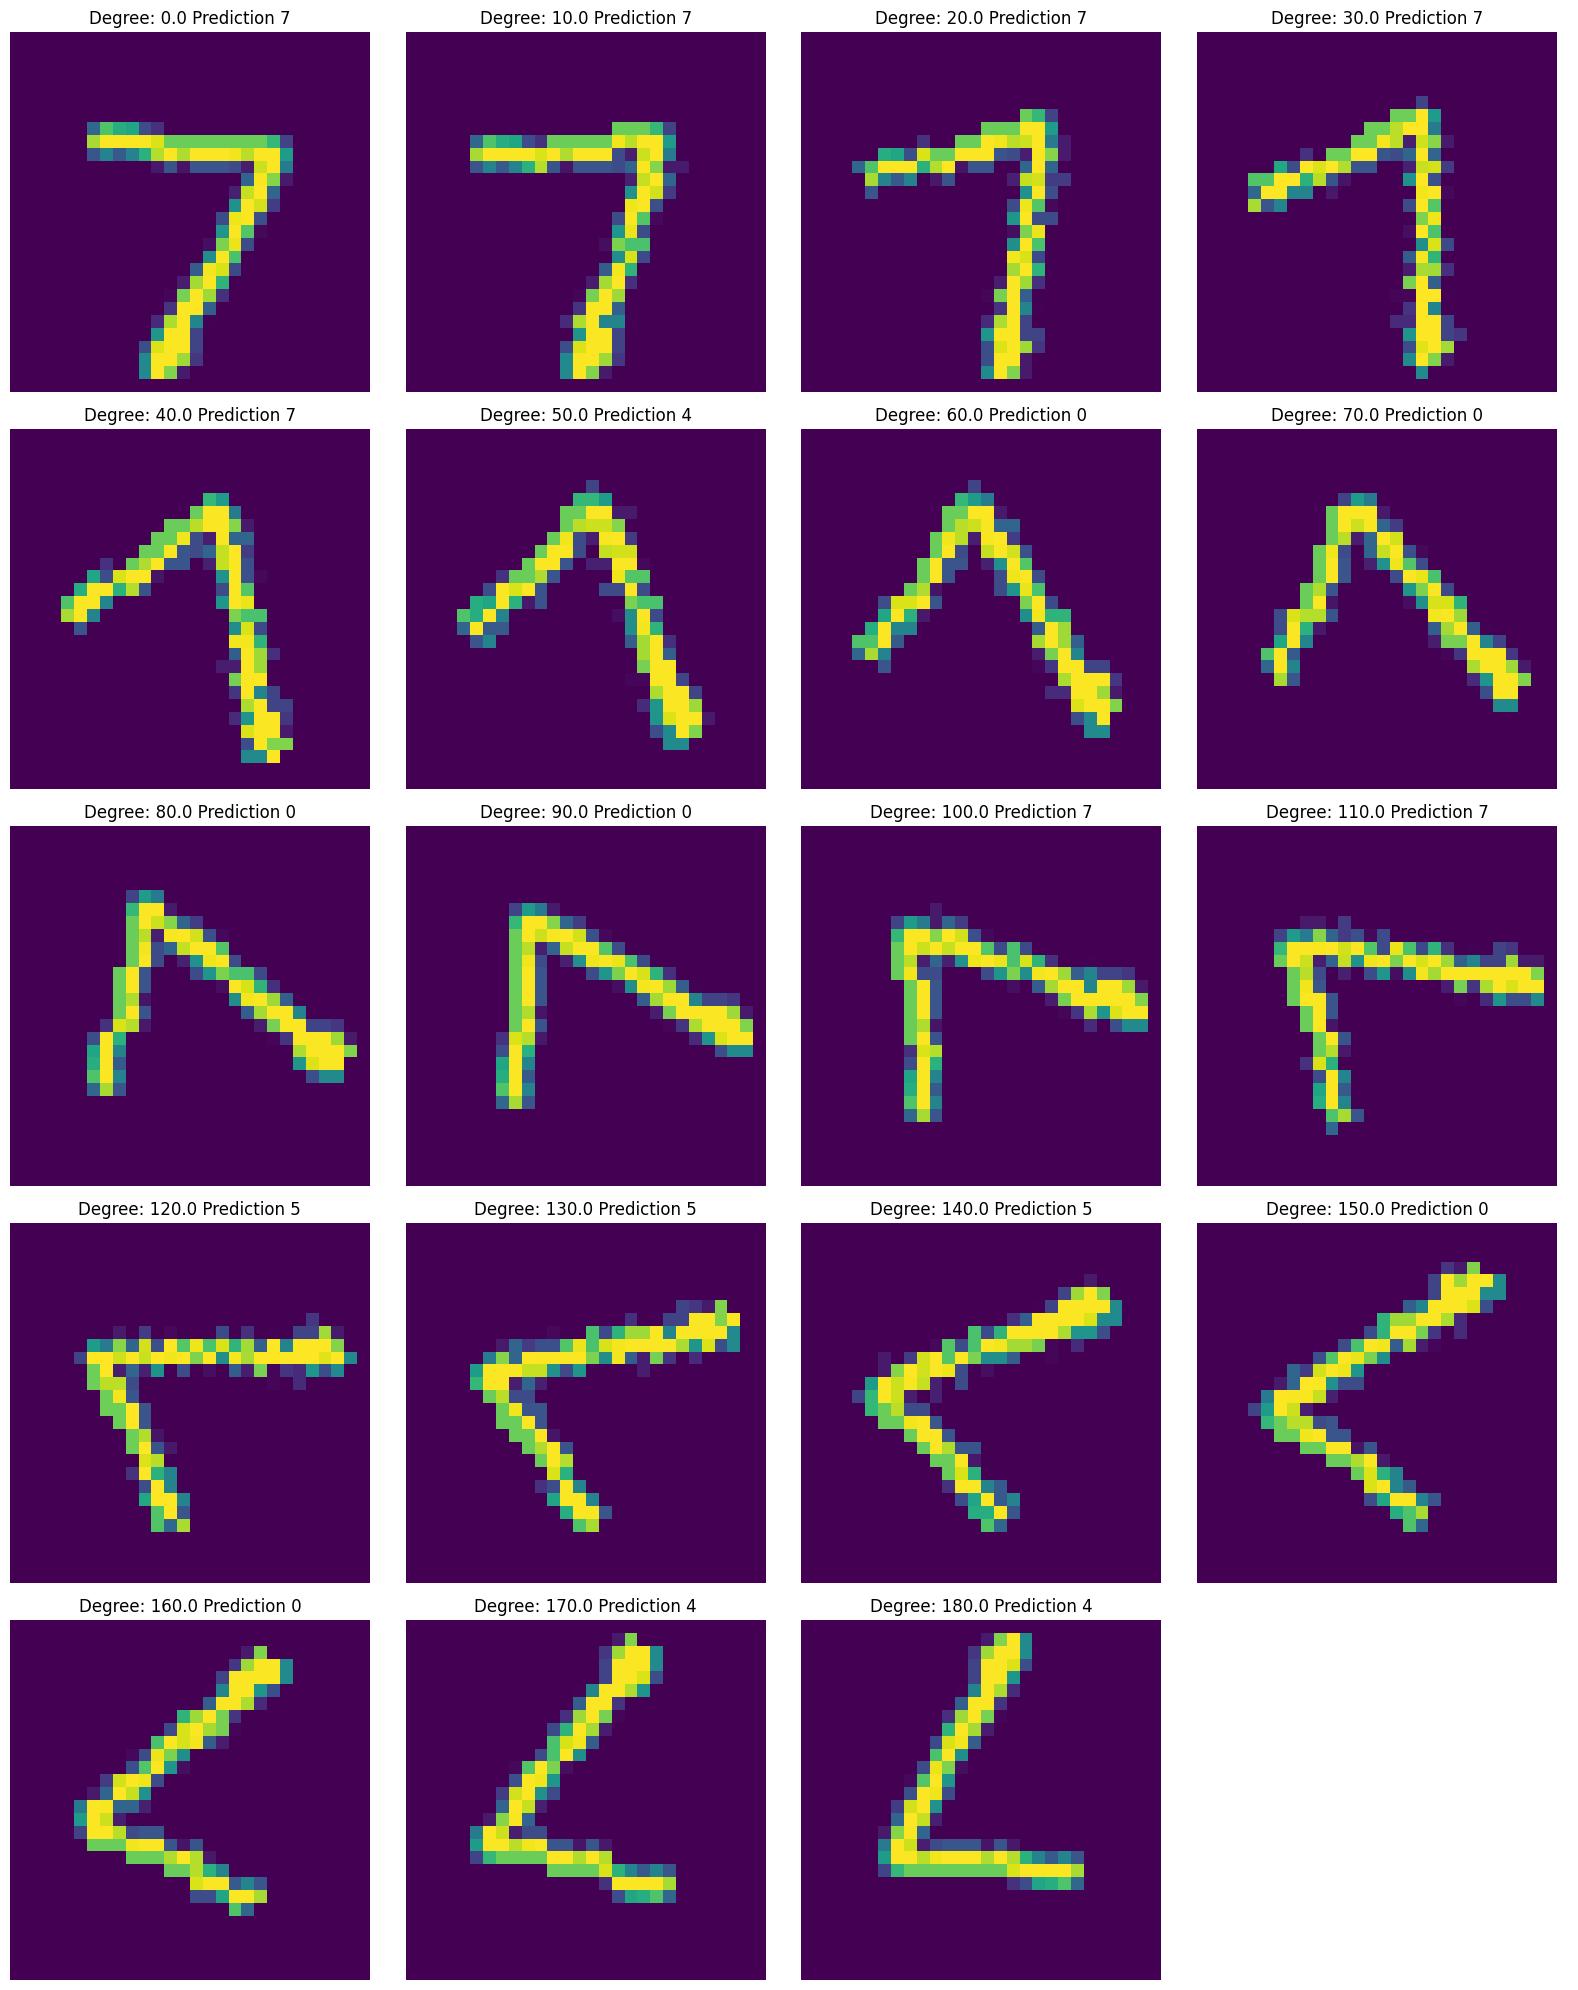

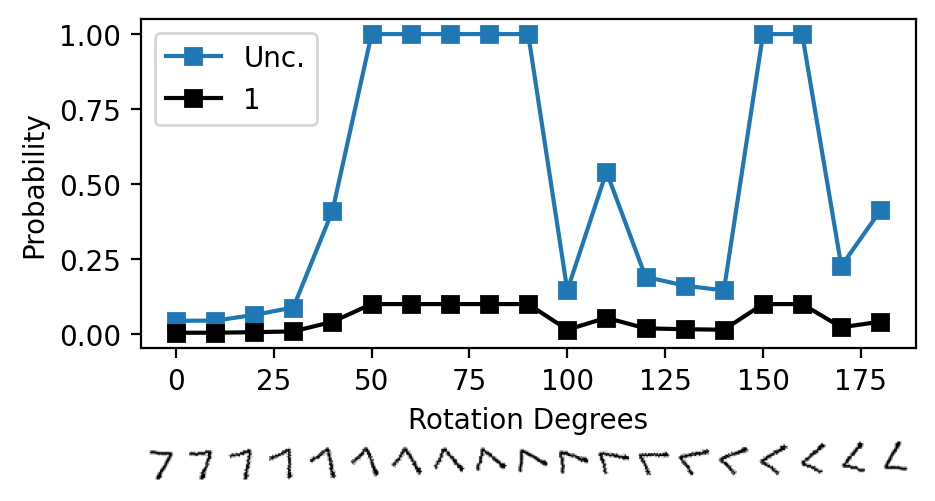

In [ ]:



rotation_uncertainty(test_data[0][0].to(device), lenet)



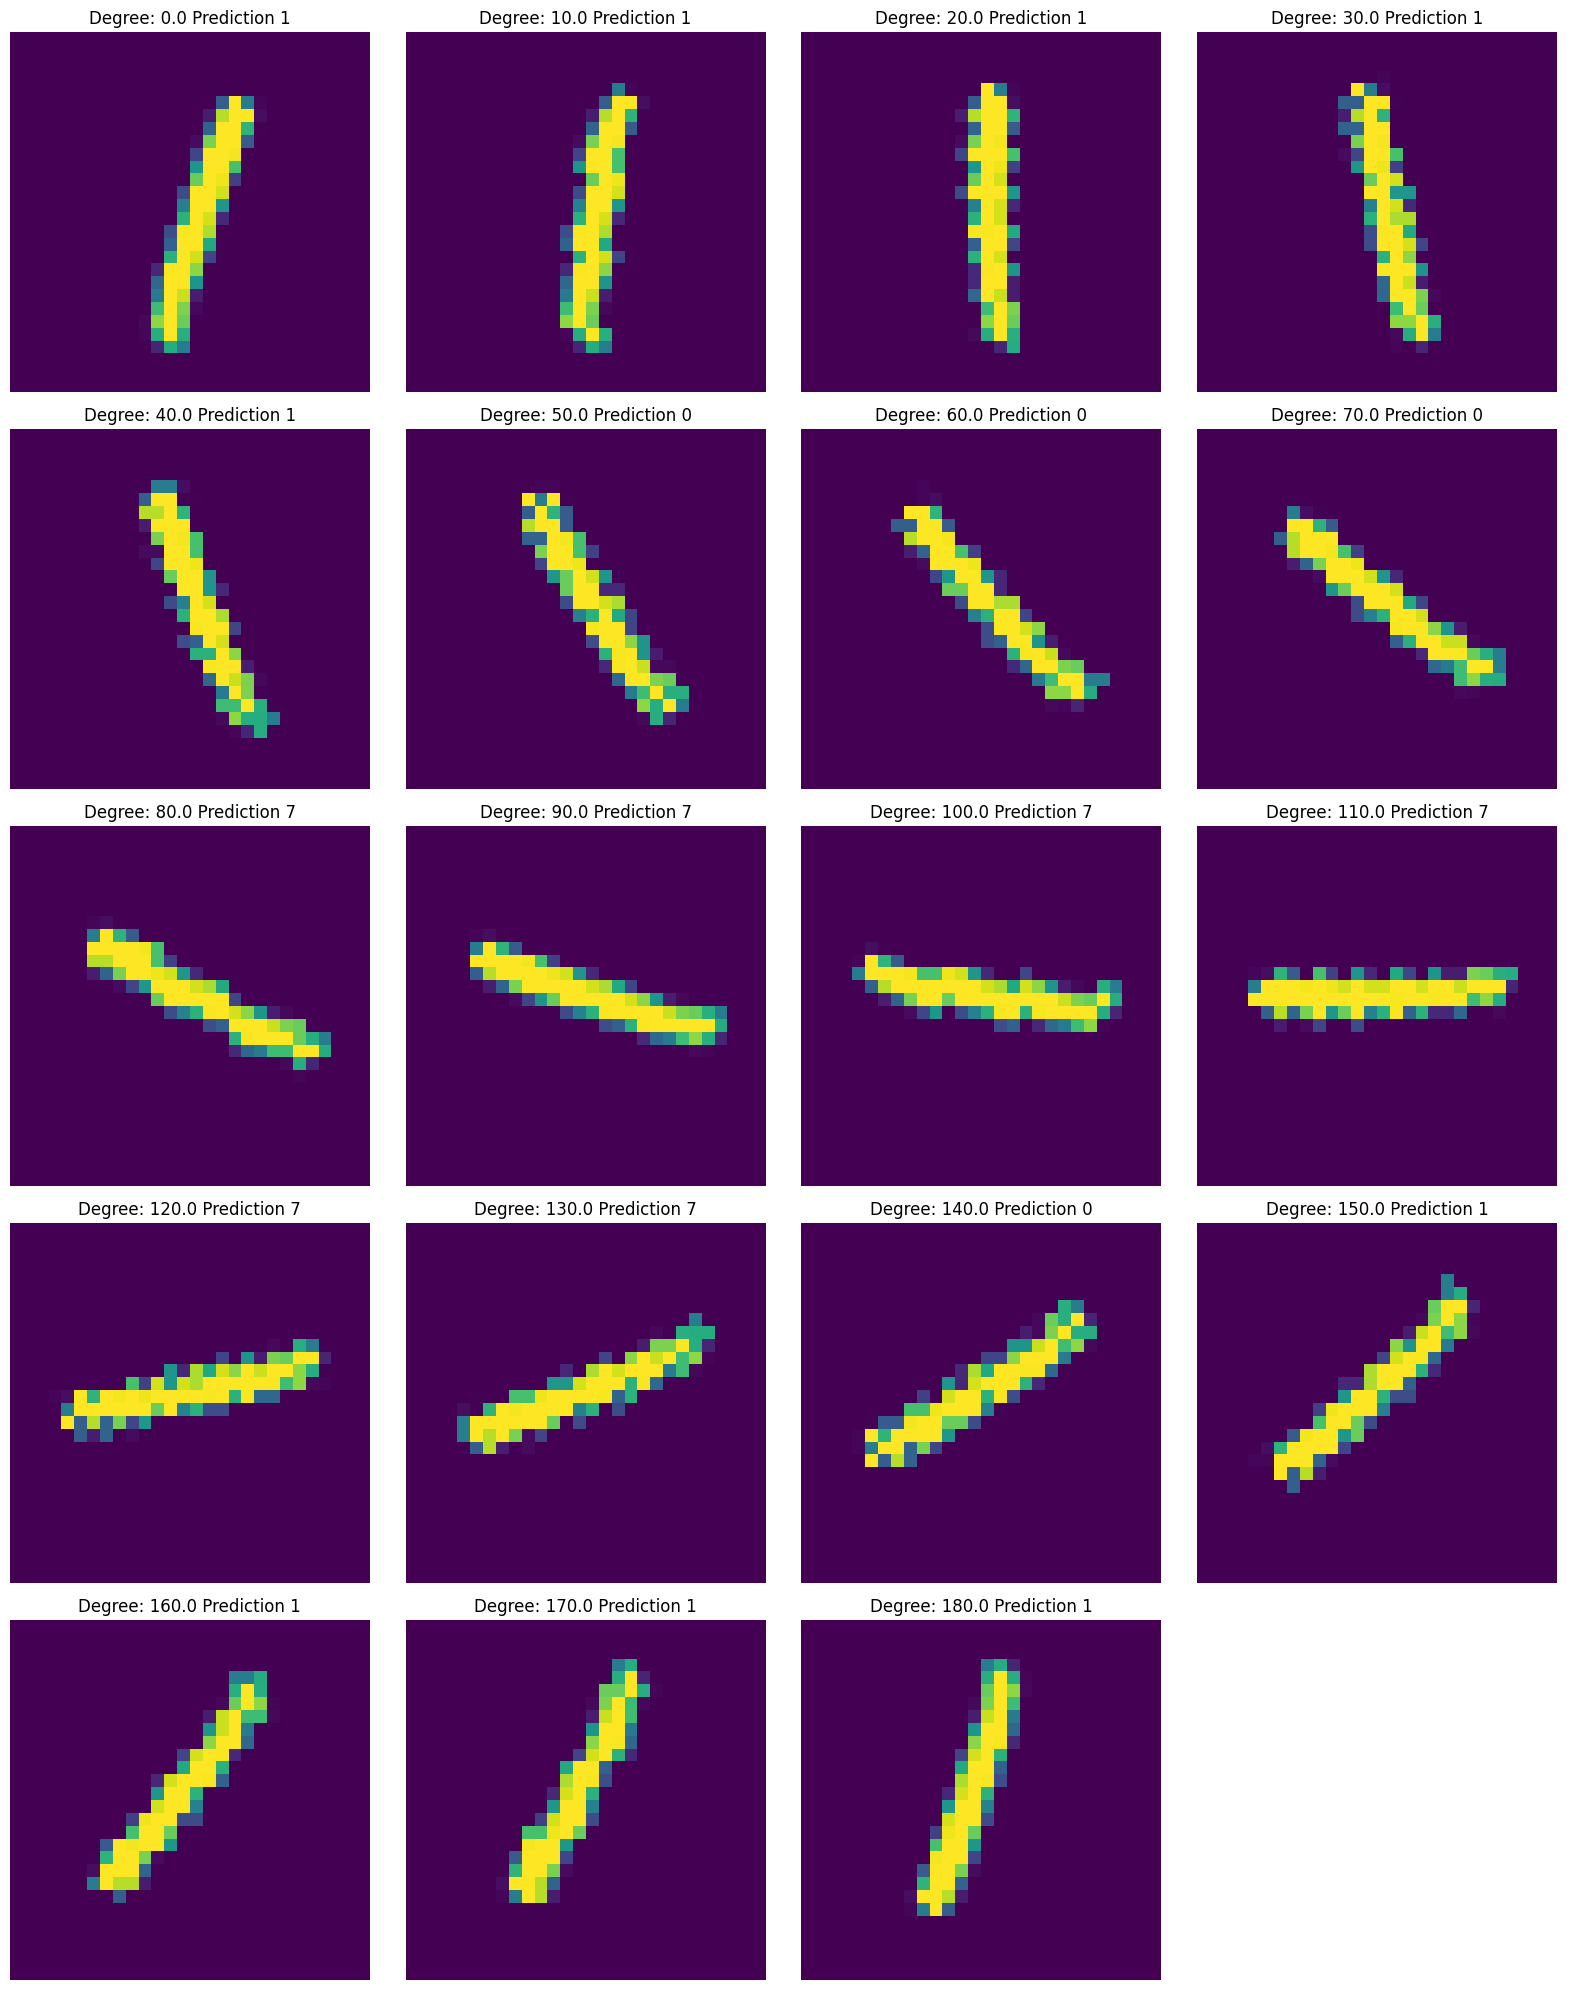

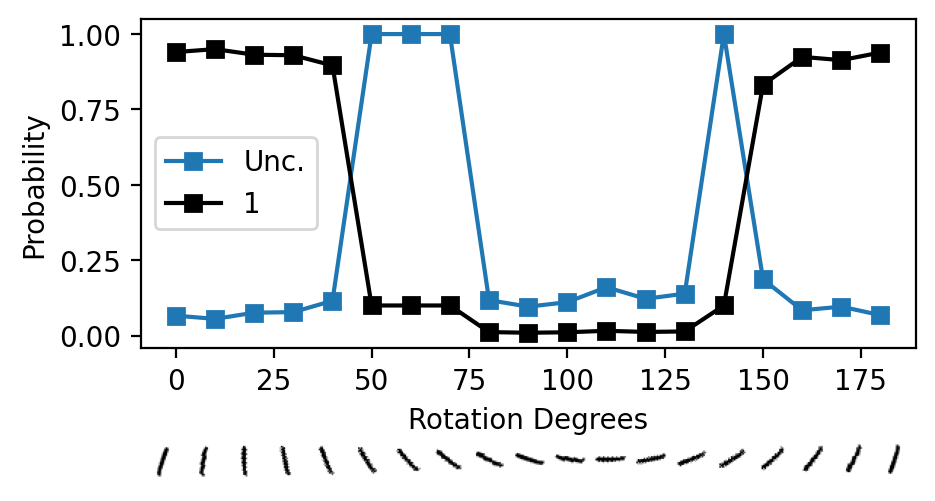

In [ ]:
rotation_uncertainty(test_data[5][0].to(device), lenet)

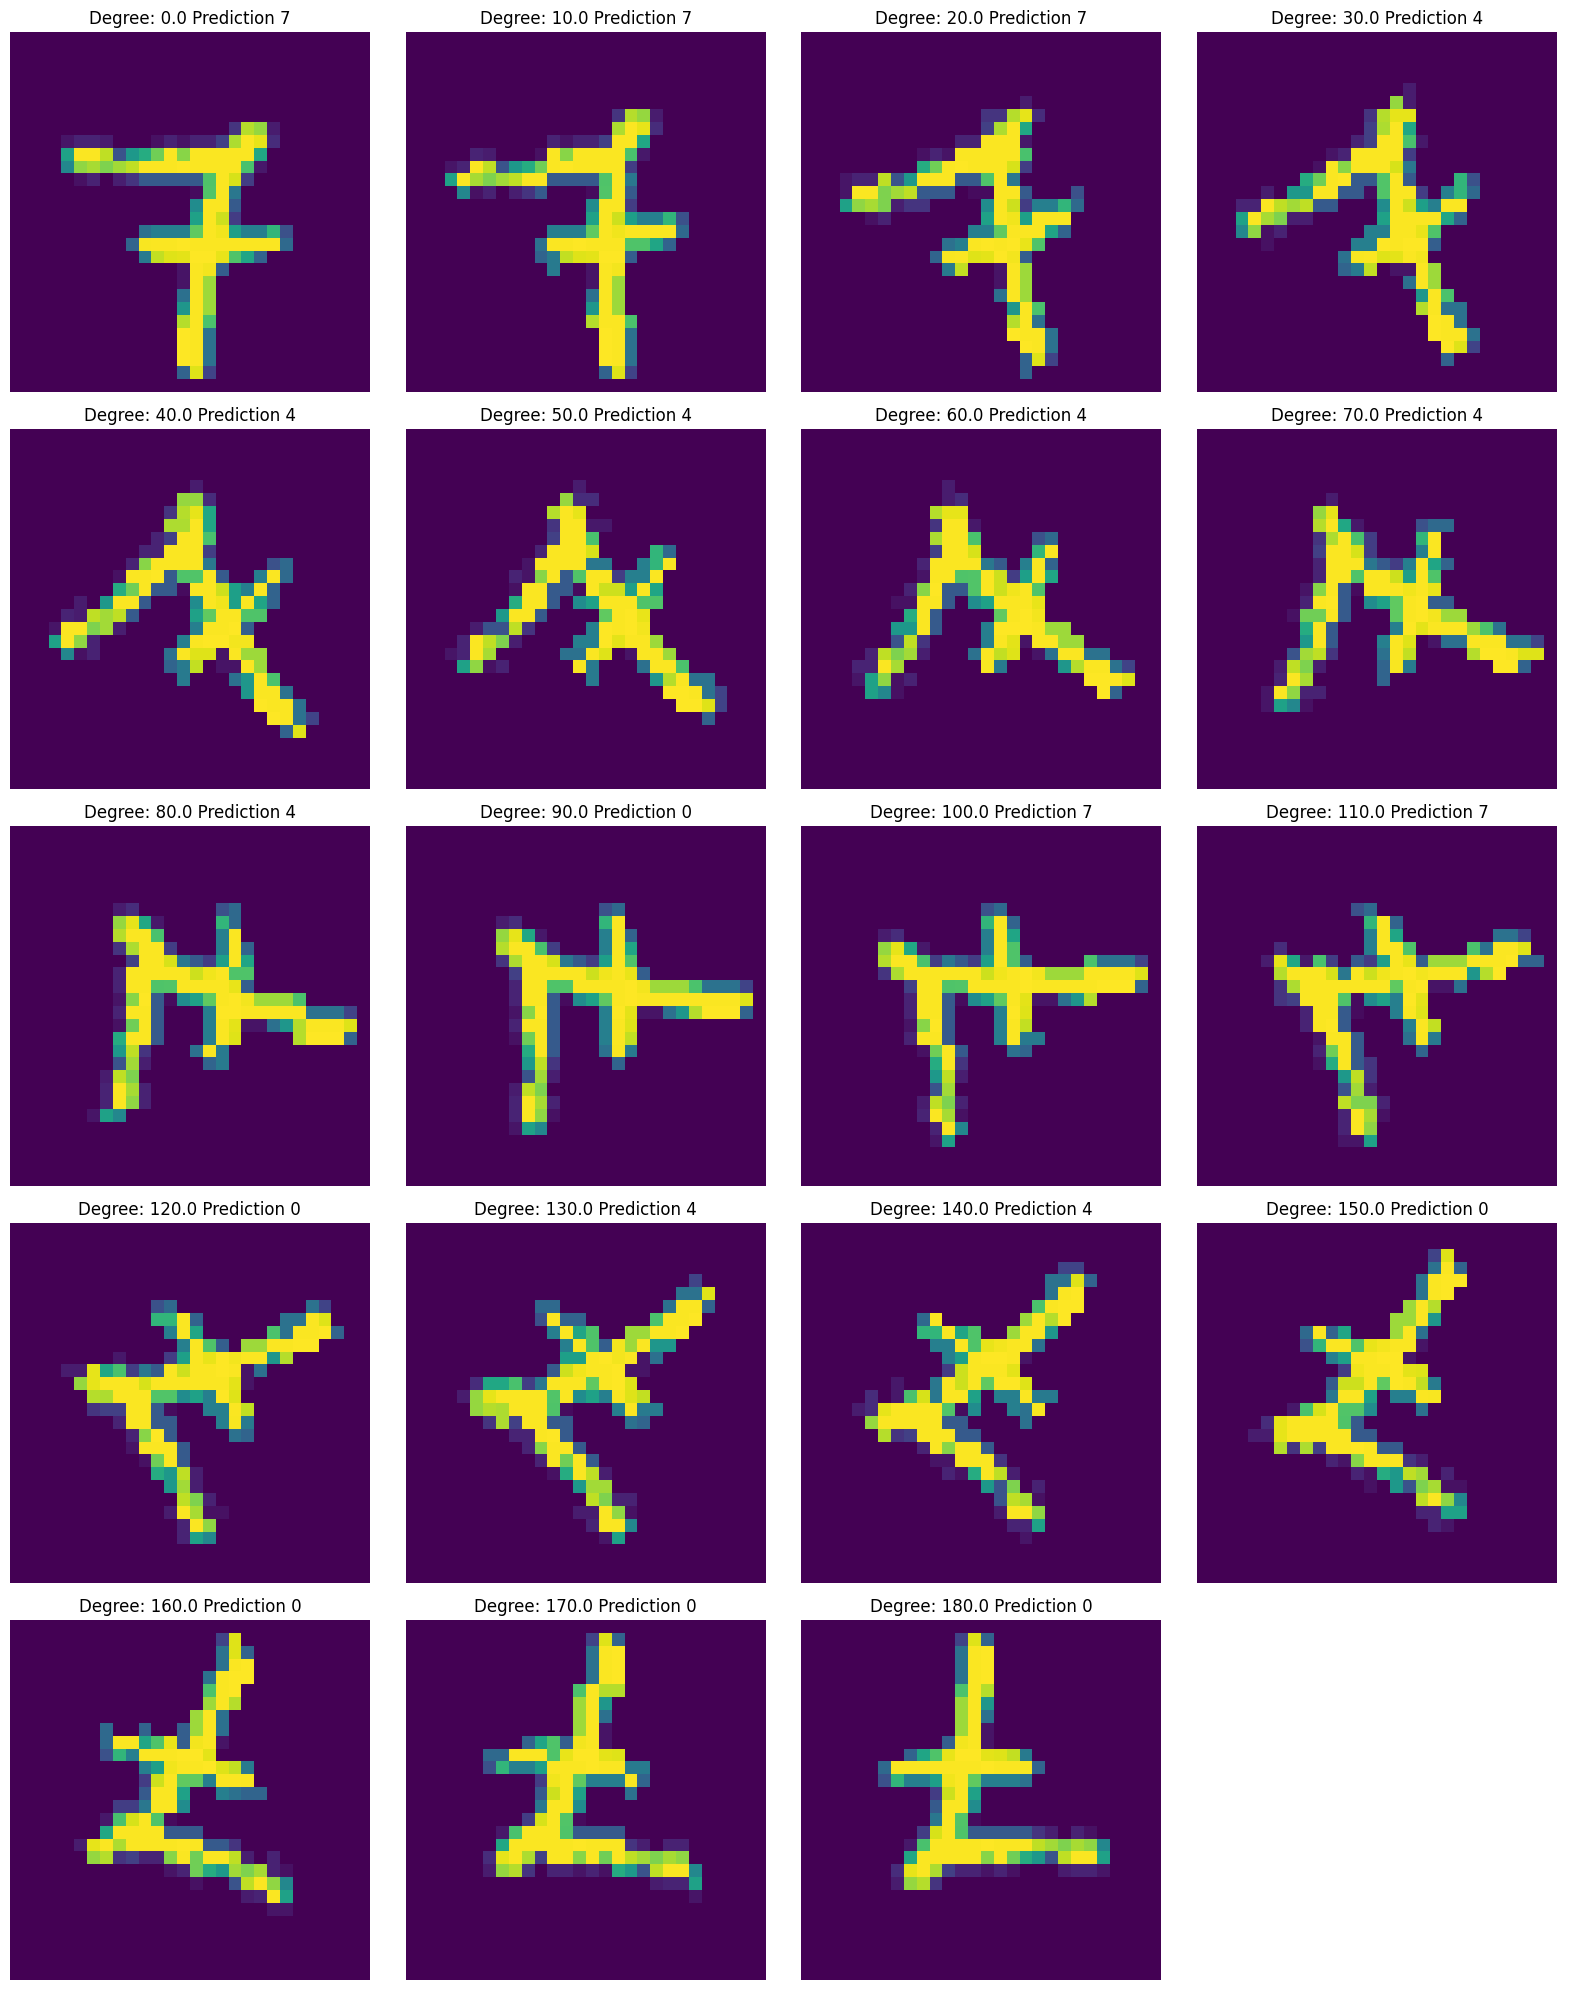

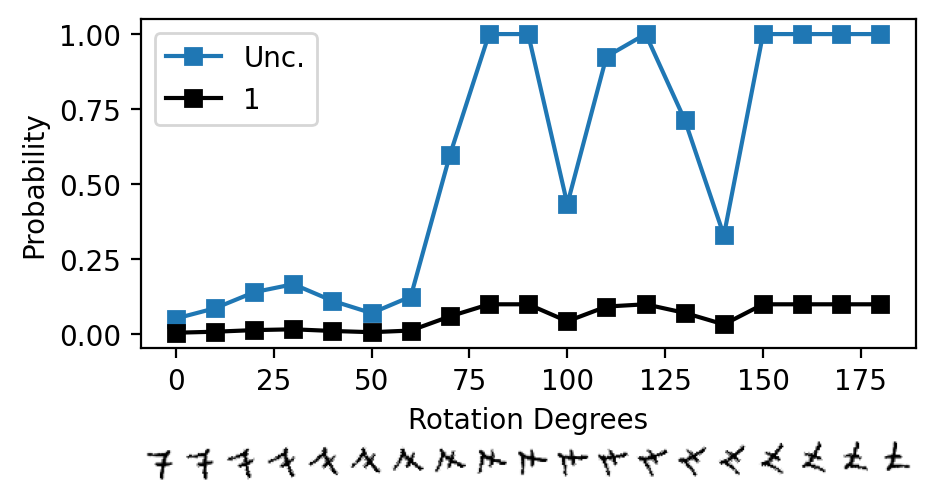

In [ ]:
rotation_uncertainty(test_data[75][0].to(device), lenet)

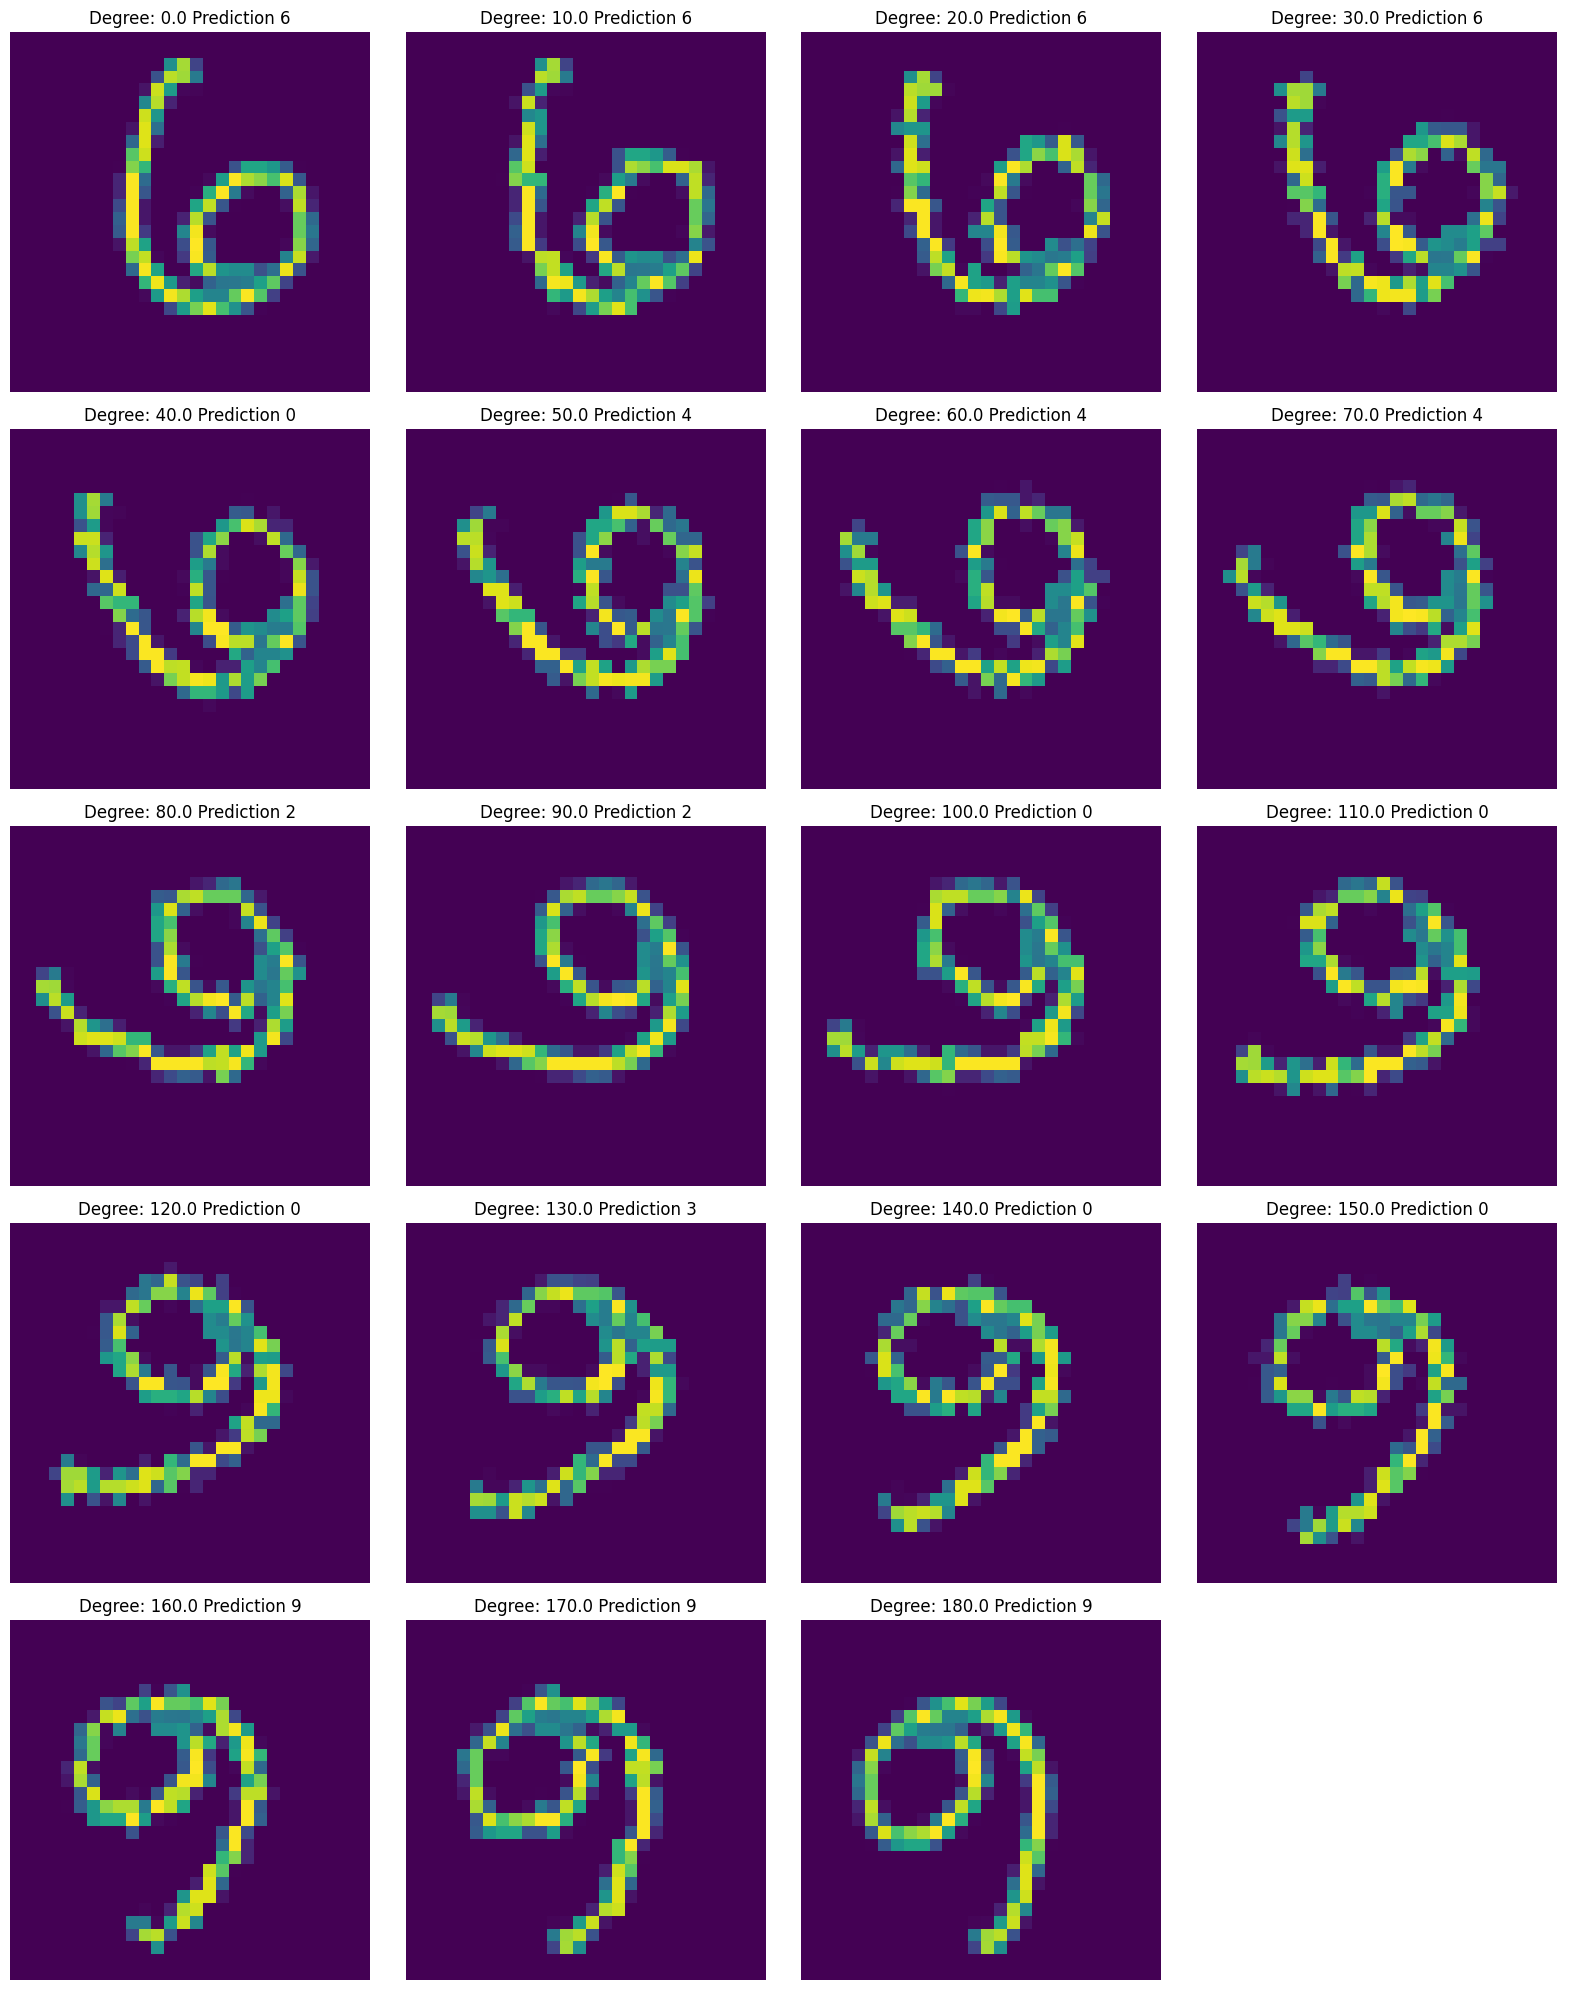

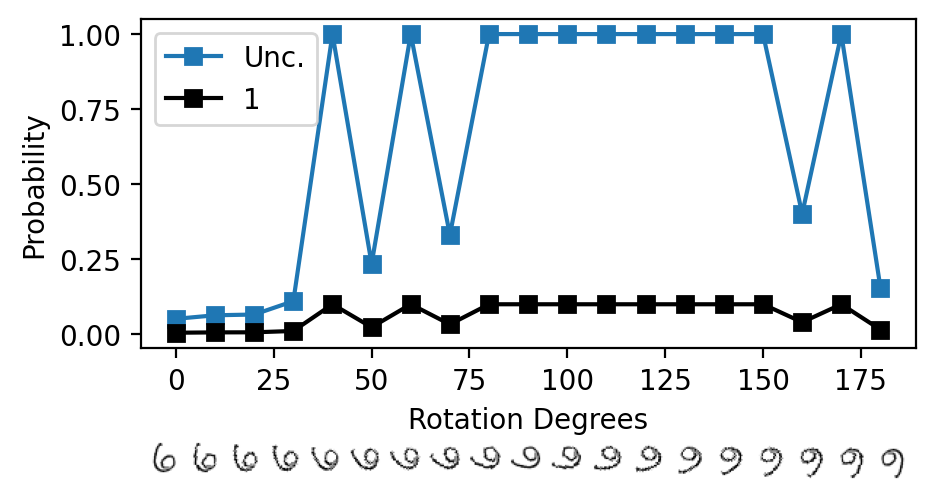

In [ ]:
rotation_uncertainty(test_data[100][0].to(device), lenet)